# Body Performance — Regression Notebook
## Predicting Broad Jump Distance (cm)

**Dataset:** bodyPerformance.csv | **Task:** Regression | **Target:** `broad jump_cm`

---
| Section | Topic |
|---------|-------|
| 1.1 | Dataset Overview |
| 1.2 | Column Understanding |
| 1.3 | Data Type Verification |
| 1.4 | Missing Values Analysis |
| 1.5 | Duplicate Detection |
| 1.6 | Data Validity Checks |
| 1.7 | Univariate Analysis |
| 1.8 | Distribution Analysis |
| 1.9 | Outlier Detection |
| 1.10 | Correlation Analysis |
| 1.11 | Final EDA Summary |
| 2 | Feature Engineering |
| 3 | Model Building & Evaluation |


## Imports & Setup

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
RANDOM_STATE = 42
print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## 1.1 Dataset Overview

First look at the dataset: size, columns, and sample rows.

In [46]:
df_raw = pd.read_csv('bodyPerformance.csv')
df     = df_raw.copy()

n_rows, n_cols = df.shape
print(f"Number of Rows    : {n_rows:,}")
print(f"Number of Columns : {n_cols}")
print()
print("Column Names:")
for idx, col in enumerate(df.columns, 1):
    print(f"  {idx:>2}. {col}")

Number of Rows    : 13,393
Number of Columns : 12

Column Names:
   1. age
   2. gender
   3. height_cm
   4. weight_kg
   5. body fat_%
   6. diastolic
   7. systolic
   8. gripForce
   9. sit and bend forward_cm
  10. sit-ups counts
  11. broad jump_cm
  12. class


### Dataset Description

The **Body Performance Dataset** contains physical fitness measurements from **13,393 individuals** across **12 columns**.
Each row records one person's demographic data (age, gender), body composition (height, weight, body fat),
cardiovascular readings (blood pressure), and four standardised fitness tests.
For this regression notebook, the **target variable is `broad jump_cm`** — the distance achieved in a
standing broad (long) jump test, measured in centimetres. This is a continuous outcome representing explosive
lower-body power and overall athletic performance. The target ranges from 0 to 303 cm with a mean of ~190 cm.
Predicting this value from other physical measurements allows us to understand which bodily attributes
most strongly determine explosive power.


---
## 1.2 Column Understanding

In [47]:
col_info = pd.DataFrame({
    'Column': ['age','gender','height_cm','weight_kg','body fat_%',
               'diastolic','systolic','gripForce',
               'sit and bend forward_cm','sit-ups counts','broad jump_cm','class'],
    'Meaning': [
        'Age of participant in years',
        'Biological sex: Male (M) or Female (F)',
        'Height in centimetres',
        'Body weight in kilograms',
        'Percentage of body mass composed of fat tissue',
        'Diastolic blood pressure (mmHg) — heart at rest',
        'Systolic blood pressure (mmHg) — heart contracting',
        'Hand grip strength by dynamometer (kg)',
        'Sit-and-reach flexibility test result (cm)',
        'Number of sit-ups completed in timed test',
        'Standing broad jump distance (cm) — TARGET',
        'Overall fitness grade: A=best, D=lowest'
    ],
    'Expected Type': ['Numeric','Categorical','Numeric','Numeric','Numeric',
                      'Numeric','Numeric','Numeric','Numeric','Numeric',
                      'Numeric (TARGET)','Categorical'],
    'Validation Rules': [
        '21-64 (adult range in dataset)',
        'M or F only',
        '> 100 cm',
        '> 0 kg, typically 30-200',
        '3-60 %',
        '40-130 mmHg',
        '60-200 mmHg',
        '>= 0 kg',
        '-30 to 80 cm',
        '0-80 (test cap)',
        '0-400 cm (target; world record ~343 cm)',
        'A, B, C, or D'
    ]
})
display(col_info)

,Column,Meaning,Expected Type,Validation Rules
0,age,Age of participant in years,Numeric,21-64 (adult range in dataset)
1,gender,Biological sex: Male (M) or Female (F),Categorical,M or F only
2,height_cm,Height in centimetres,Numeric,> 100 cm
3,weight_kg,Body weight in kilograms,Numeric,"> 0 kg, typically 30-200"
4,body fat_%,Percentage of body mass composed of fat tissue,Numeric,3-60 %
5,diastolic,Diastolic blood pressure (mmHg) — heart at rest,Numeric,40-130 mmHg
6,systolic,Systolic blood pressure (mmHg) — heart contrac...,Numeric,60-200 mmHg
7,gripForce,Hand grip strength by dynamometer (kg),Numeric,>= 0 kg
8,sit and bend forward_cm,Sit-and-reach flexibility test result (cm),Numeric,-30 to 80 cm
9,sit-ups counts,Number of sit-ups completed in timed test,Numeric,0-80 (test cap)


---
## 1.3 Data Type Verification

In [48]:
dtype_df = df.dtypes.rename('Detected Type').to_frame()
dtype_df['Expected Type'] = ['Numeric','Categorical','Numeric','Numeric','Numeric',
                              'Numeric','Numeric','Numeric','Numeric','Numeric','Numeric','Categorical']
dtype_df['Match'] = dtype_df.apply(
    lambda r: 'Correct' if (
        (r['Expected Type']=='Numeric'     and r['Detected Type'] in ['float64','int64']) or
        (r['Expected Type']=='Categorical' and str(r['Detected Type']) in ['object','str','string'])
    ) else 'MISMATCH', axis=1)
display(dtype_df)

print()
print("Findings:")
print("  - All numeric columns are float64 — correct for mathematical operations.")
print("  - 'age' and 'sit-ups counts' are float64 but represent integer values.")
print("    This is not a critical issue; calculations will still be valid.")
print("  - 'gender' and 'class' are stored as object — correct for categorical data.")
print("  - 'broad jump_cm' (our regression target) is correctly float64.")
print("  - No type mismatches require mandatory correction.")

,Detected Type,Expected Type,Match
age,float64,Numeric,Correct
gender,object,Categorical,Correct
height_cm,float64,Numeric,Correct
weight_kg,float64,Numeric,Correct
body fat_%,float64,Numeric,Correct
diastolic,float64,Numeric,Correct
systolic,float64,Numeric,Correct
gripForce,float64,Numeric,Correct
sit and bend forward_cm,float64,Numeric,Correct
sit-ups counts,float64,Numeric,Correct



Findings:
  - All numeric columns are float64 — correct for mathematical operations.
  - 'age' and 'sit-ups counts' are float64 but represent integer values.
    This is not a critical issue; calculations will still be valid.
  - 'gender' and 'class' are stored as object — correct for categorical data.
  - 'broad jump_cm' (our regression target) is correctly float64.
  - No type mismatches require mandatory correction.


---
## 1.4 Missing Values Analysis

In [49]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(4)

def assign_strategy(col, pct, series):
    if pct == 0:
        return 'None needed'
    elif pct < 5:
        return 'Drop rows (< 5% impact)'
    elif pct < 30:
        if series.dtype == 'object':
            return 'Fill with Mode'
        elif abs(series.skew()) > 1:
            return 'Fill with Median (skewed)'
        else:
            return 'Fill with Mean (normal)'
    else:
        return 'Drop column (> 30% missing)'

missing_df = pd.DataFrame({'Missing Count': null_counts, 'Missing %': null_pct})
missing_df['Strategy'] = [assign_strategy(c, null_pct[c], df[c]) for c in df.columns]
display(missing_df)

print()
if null_counts.sum() == 0:
    print("RESULT: No missing values in any column. No imputation needed.")
else:
    for col in missing_df.index:
        strat = missing_df.loc[col, 'Strategy']
        if 'Drop rows' in strat:
            df.dropna(subset=[col], inplace=True)
        elif 'Median' in strat:
            df[col].fillna(df[col].median(), inplace=True)
        elif 'Mean' in strat:
            df[col].fillna(df[col].mean(), inplace=True)
        elif 'Mode' in strat:
            df[col].fillna(df[col].mode()[0], inplace=True)
        elif 'Drop column' in strat:
            df.drop(columns=[col], inplace=True)
    print(f"Shape after handling: {df.shape}")

,Missing Count,Missing %,Strategy
age,0,0.000,None needed
gender,0,0.000,None needed
height_cm,0,0.000,None needed
weight_kg,0,0.000,None needed
body fat_%,0,0.000,None needed
diastolic,0,0.000,None needed
systolic,0,0.000,None needed
gripForce,0,0.000,None needed
sit and bend forward_cm,0,0.000,None needed
sit-ups counts,0,0.000,None needed



RESULT: No missing values in any column. No imputation needed.


---
## 1.5 Duplicate Detection

In [50]:
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows found: {n_dupes}")

if n_dupes > 0:
    print("Duplicate rows:")
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)))
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found. No action required.")

Exact duplicate rows found: 1
Duplicate rows:


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
8965,27.000,F,157.000,49.100,30.700,70.000,86.000,27.700,19.700,51.000,167.000,A
12473,27.000,F,157.000,49.100,30.700,70.000,86.000,27.700,19.700,51.000,167.000,A


Duplicates removed. New shape: (13392, 12)


---
## 1.6 Data Validity Checks

Detect values that are logically or physiologically impossible.

In [51]:
print("=== Validity Check Report ===")
print()

checks = [
    ('systolic',                df['systolic'] <= 40,
     'Systolic BP <= 40 mmHg (impossible for living person)'),
    ('diastolic',               df['diastolic'] <= 40,
     'Diastolic BP <= 40 mmHg (impossible for living person)'),
    ('broad jump_cm',           df['broad jump_cm'] == 0,
     'Broad jump = 0 cm (no attempt or measurement error)'),
    ('broad jump_cm',           df['broad jump_cm'] > 400,
     'Broad jump > 400 cm (exceeds world record of 343 cm)'),
    ('body fat_%',              df['body fat_%'] > 70,
     'Body fat > 70% (extreme/impossible)'),
    ('sit and bend forward_cm', df['sit and bend forward_cm'] > 100,
     'Sit-and-reach > 100 cm (beyond anatomical limit)'),
    ('gripForce',               df['gripForce'] < 0,
     'Negative grip force (impossible)'),
    ('gender',                  ~df['gender'].isin(['M','F']),
     "Invalid gender label"),
    ('class',                   ~df['class'].isin(['A','B','C','D']),
     "Invalid class label"),
]

for col, mask, description in checks:
    count = int(mask.sum())
    tag = f"VIOLATION ({count} rows)" if count > 0 else "OK"
    print(f"  [{tag:<22}]  {description}")

print()
print("Action Plan:")
print("  1. REMOVE rows with BP <= 40 (physiologically dead / data entry error).")
print("  2. CAP sit-and-reach extreme values at anatomical limits.")
print("  3. RETAIN broad jump = 0 (genuine test failures; informative for regression).")
print("  4. No impossible broad jump values > 400 found.")

=== Validity Check Report ===

  [VIOLATION (2 rows)    ]  Systolic BP <= 40 mmHg (impossible for living person)
  [VIOLATION (6 rows)    ]  Diastolic BP <= 40 mmHg (impossible for living person)
  [VIOLATION (10 rows)   ]  Broad jump = 0 cm (no attempt or measurement error)
  [OK                    ]  Broad jump > 400 cm (exceeds world record of 343 cm)
  [VIOLATION (1 rows)    ]  Body fat > 70% (extreme/impossible)
  [VIOLATION (2 rows)    ]  Sit-and-reach > 100 cm (beyond anatomical limit)
  [OK                    ]  Negative grip force (impossible)
  [OK                    ]  Invalid gender label
  [OK                    ]  Invalid class label

Action Plan:
  1. REMOVE rows with BP <= 40 (physiologically dead / data entry error).
  2. CAP sit-and-reach extreme values at anatomical limits.
  3. RETAIN broad jump = 0 (genuine test failures; informative for regression).
  4. No impossible broad jump values > 400 found.


In [52]:
before = len(df)
df = df[(df['systolic'] > 40) & (df['diastolic'] > 40)]
print(f"Rows removed (BP <= 40): {before - len(df)}")

old_max = df['sit and bend forward_cm'].max()
df['sit and bend forward_cm'] = df['sit and bend forward_cm'].clip(lower=-25, upper=80)
print(f"sit-and-reach capped — old max was {old_max:.1f}, now capped at 80")
print(f"Dataset shape after fixes: {df.shape}")

Rows removed (BP <= 40): 7
sit-and-reach capped — old max was 213.0, now capped at 80
Dataset shape after fixes: (13385, 12)


---
## 1.7 Univariate Analysis

Descriptive statistics for all numeric columns including the regression target.

In [53]:
NUM_COLS = ['age','height_cm','weight_kg','body fat_%','diastolic',
            'systolic','gripForce','sit and bend forward_cm',
            'sit-ups counts','broad jump_cm']

stats_table = df[NUM_COLS].agg(['mean','median','std','min','max']).T
stats_table.columns = ['Mean','Median','Std Dev','Min','Max']
stats_table['Skewness'] = df[NUM_COLS].skew().round(3)
stats_table = stats_table.round(3)

print("Descriptive Statistics:")
display(stats_table)

print()
print("=== Target Variable: broad jump_cm ===")
bj = df['broad jump_cm']
print(f"  Mean   : {bj.mean():.2f} cm")
print(f"  Median : {bj.median():.2f} cm")
print(f"  Std Dev: {bj.std():.2f} cm")
print(f"  Min    : {bj.min():.2f} cm")
print(f"  Max    : {bj.max():.2f} cm")
print(f"  Skew   : {bj.skew():.3f} (slight left skew — most participants cluster at moderate performance)")
print()
print("=== Predictor Interpretation Notes ===")
notes = [
    ('age',                     'Mean 36.8yr, right-skewed (0.60). Older participants expected to jump shorter distances.'),
    ('height_cm',               'Mean 168.6cm, near-symmetric. Taller individuals generally jump further.'),
    ('weight_kg',               'Mean 67.1kg, slight right skew. Heavier mass can aid jump via muscle, but also increases load.'),
    ('body fat_%',              'Mean 24.0%, right-skewed. High body fat is expected to reduce jump distance.'),
    ('gripForce',               'Mean 36.9kg, near-symmetric. Strong proxy for overall muscular strength.'),
    ('sit-ups counts',          'Mean 39.8 reps, slight left skew. Core endurance linked to athletic output.'),
    ('diastolic / systolic',    'Near-normal distributions. Indirect link to cardiovascular fitness.'),
]
for col, note in notes:
    print(f"  {col:<30}: {note}")

Descriptive Statistics:


,Mean,Median,Std Dev,Min,Max,Skewness
age,36.777,32.000,13.626,21.000,64.000,0.600
height_cm,168.563,169.200,8.426,125.000,193.800,-0.187
weight_kg,67.451,67.440,11.949,26.300,138.100,0.350
body fat_%,23.238,22.800,7.257,3.000,78.400,0.362
diastolic,78.825,79.000,10.667,41.000,156.200,-0.080
systolic,130.263,130.000,14.626,43.900,201.000,0.041
gripForce,36.965,37.900,10.624,0.000,70.500,0.018
sit and bend forward_cm,15.192,16.200,8.190,-25.000,80.000,-0.772
sit-ups counts,39.771,41.000,14.275,0.000,80.000,-0.468
broad jump_cm,190.139,193.000,39.867,0.000,303.000,-0.423



=== Target Variable: broad jump_cm ===
  Mean   : 190.14 cm
  Median : 193.00 cm
  Std Dev: 39.87 cm
  Min    : 0.00 cm
  Max    : 303.00 cm
  Skew   : -0.423 (slight left skew — most participants cluster at moderate performance)

=== Predictor Interpretation Notes ===
  age                           : Mean 36.8yr, right-skewed (0.60). Older participants expected to jump shorter distances.
  height_cm                     : Mean 168.6cm, near-symmetric. Taller individuals generally jump further.
  weight_kg                     : Mean 67.1kg, slight right skew. Heavier mass can aid jump via muscle, but also increases load.
  body fat_%                    : Mean 24.0%, right-skewed. High body fat is expected to reduce jump distance.
  gripForce                     : Mean 36.9kg, near-symmetric. Strong proxy for overall muscular strength.
  sit-ups counts                : Mean 39.8 reps, slight left skew. Core endurance linked to athletic output.
  diastolic / systolic          : Near-nor

---
## 1.8 Distribution Analysis

Histograms reveal shape, skewness, bimodality, and target distribution.

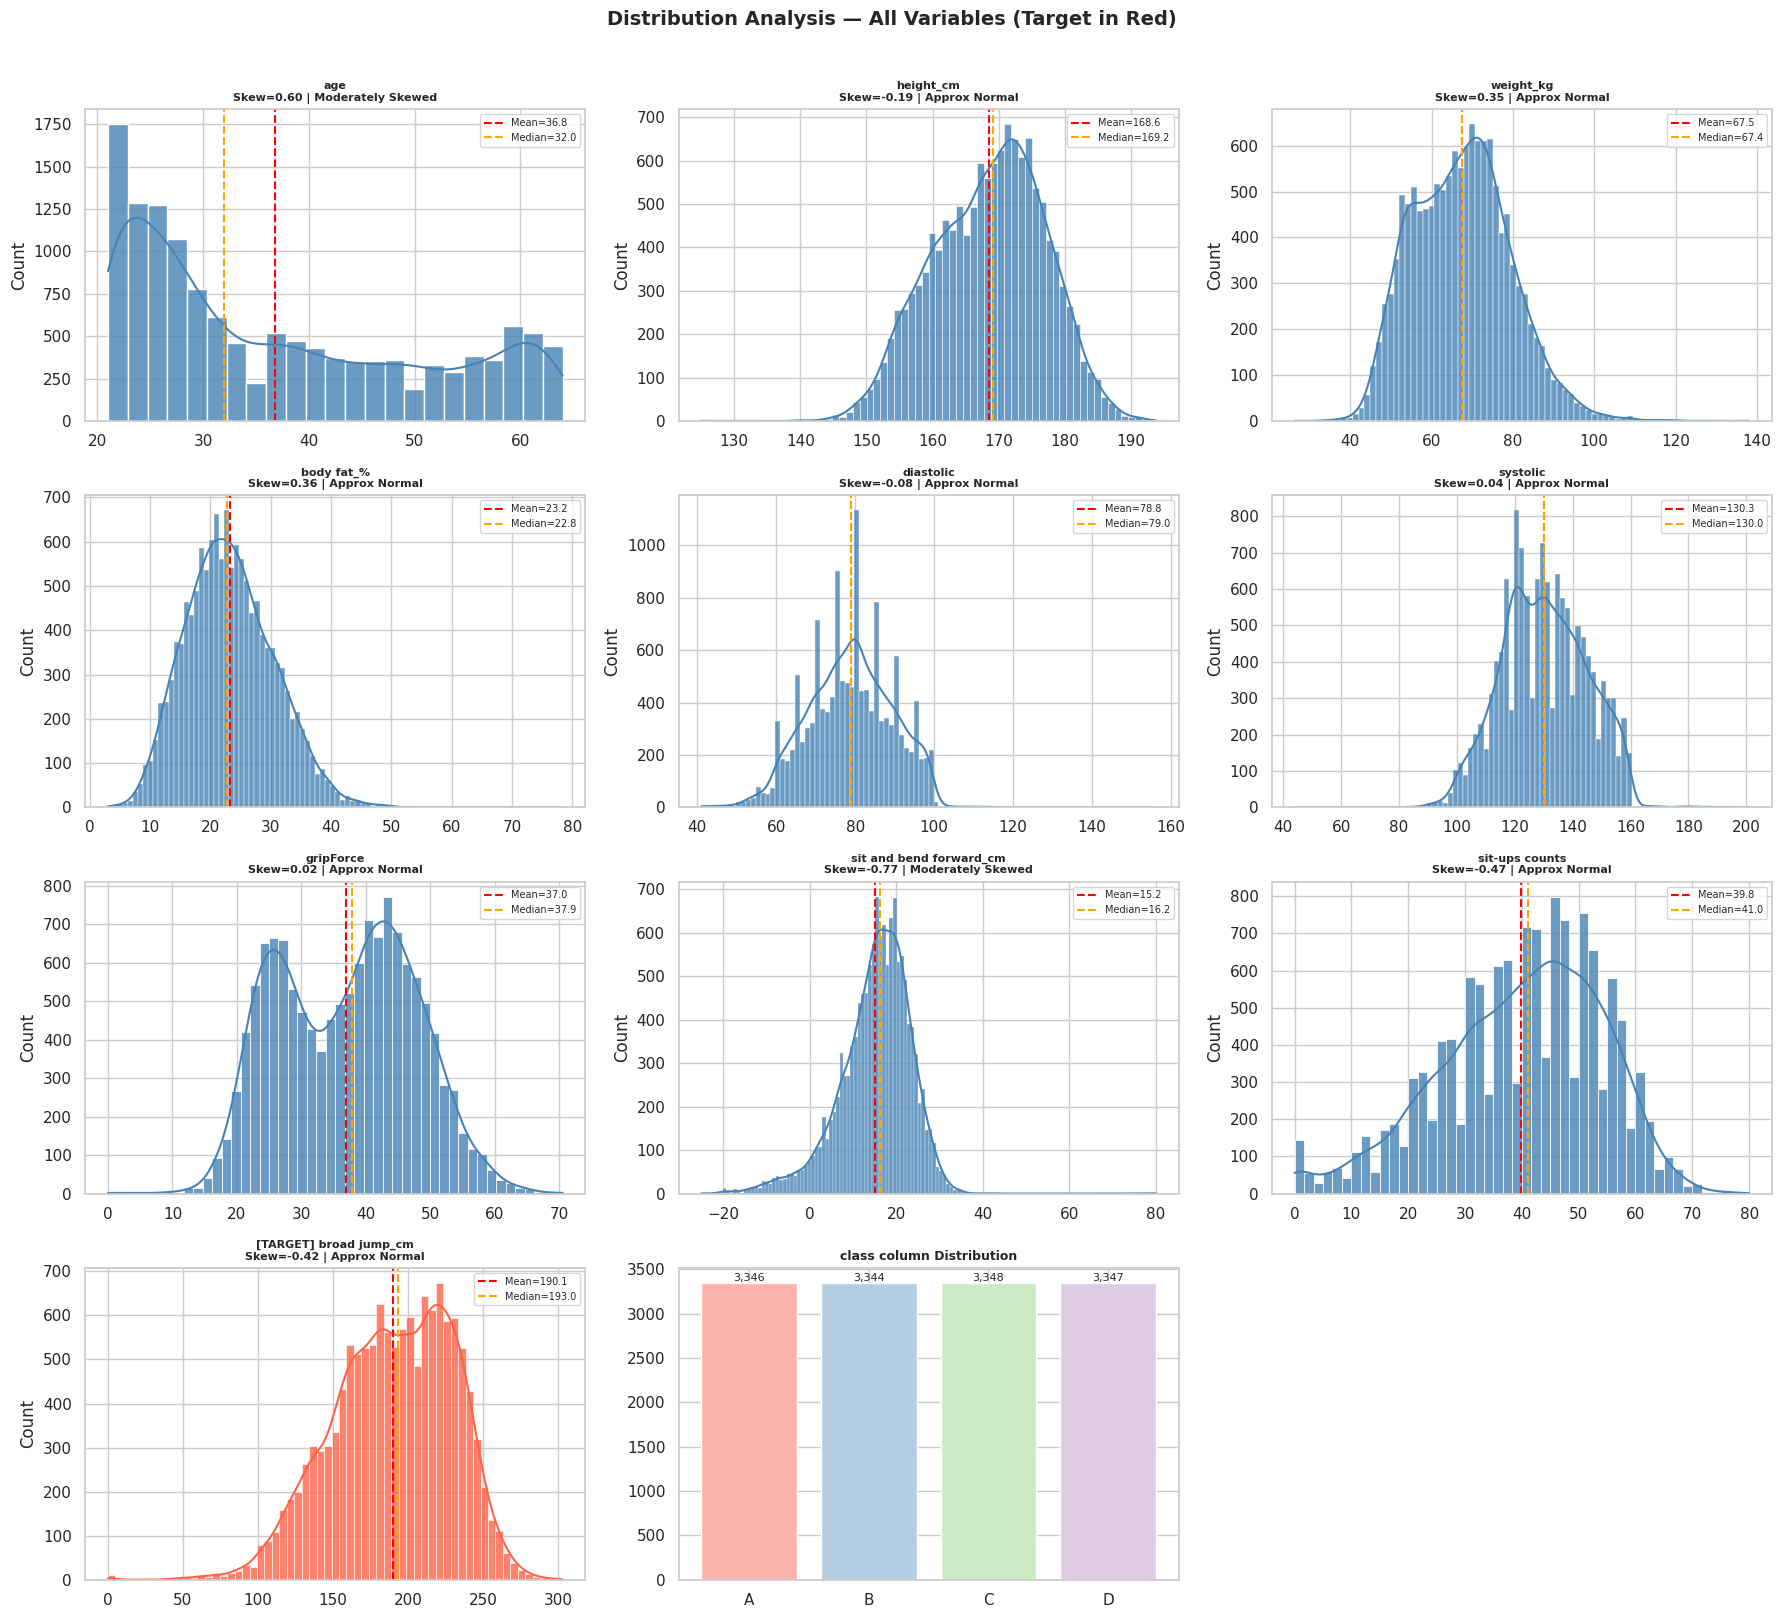

=== Distribution Key Findings ===
  broad jump_cm   : Left-skewed (target) — most cluster at moderate values ~190cm.
  gripForce       : Bimodal — distinct male/female peaks; strong predictor expected.
  height_cm       : Bimodal — male/female subpopulation peaks.
  body fat_%      : Right-skewed — high-fat outliers present; important for regression.
  age             : Right-skewed — more younger people; age negatively linked to jump.
  sit-ups         : Slight left skew — most achieve moderate counts.


In [54]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for idx, col in enumerate(NUM_COLS):
    ax = axes[idx]
    series = df[col].dropna()
    skew_val = series.skew()

    is_target = col == 'broad jump_cm'
    color = 'tomato' if is_target else 'steelblue'

    sns.histplot(series, kde=True, ax=ax, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(series.mean(),   color='red',    ls='--', lw=1.5, label=f'Mean={series.mean():.1f}')
    ax.axvline(series.median(), color='orange', ls='--', lw=1.5, label=f'Median={series.median():.1f}')

    shape = ('Highly Skewed' if abs(skew_val) > 1 else
             'Moderately Skewed' if abs(skew_val) > 0.5 else 'Approx Normal')
    title = f'{col}\nSkew={skew_val:.2f} | {shape}'
    if is_target:
        title = '[TARGET] ' + title
    ax.set_title(title, fontsize=8, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_xlabel('')

# Class distribution (supplementary)
ax = axes[len(NUM_COLS)]
class_counts = df['class'].value_counts().sort_index()
bars = ax.bar(class_counts.index, class_counts.values,
              color=sns.color_palette('Pastel1', 4), edgecolor='white')
ax.set_title('class column Distribution', fontsize=9, fontweight='bold')
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{val:,}', ha='center', fontsize=8)

for j in range(len(NUM_COLS)+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution Analysis — All Variables (Target in Red)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("=== Distribution Key Findings ===")
print("  broad jump_cm   : Left-skewed (target) — most cluster at moderate values ~190cm.")
print("  gripForce       : Bimodal — distinct male/female peaks; strong predictor expected.")
print("  height_cm       : Bimodal — male/female subpopulation peaks.")
print("  body fat_%      : Right-skewed — high-fat outliers present; important for regression.")
print("  age             : Right-skewed — more younger people; age negatively linked to jump.")
print("  sit-ups         : Slight left skew — most achieve moderate counts.")

---
## 1.9 Outlier Detection

Boxplots identify outliers. Regression is sensitive to outliers — each decision is justified.

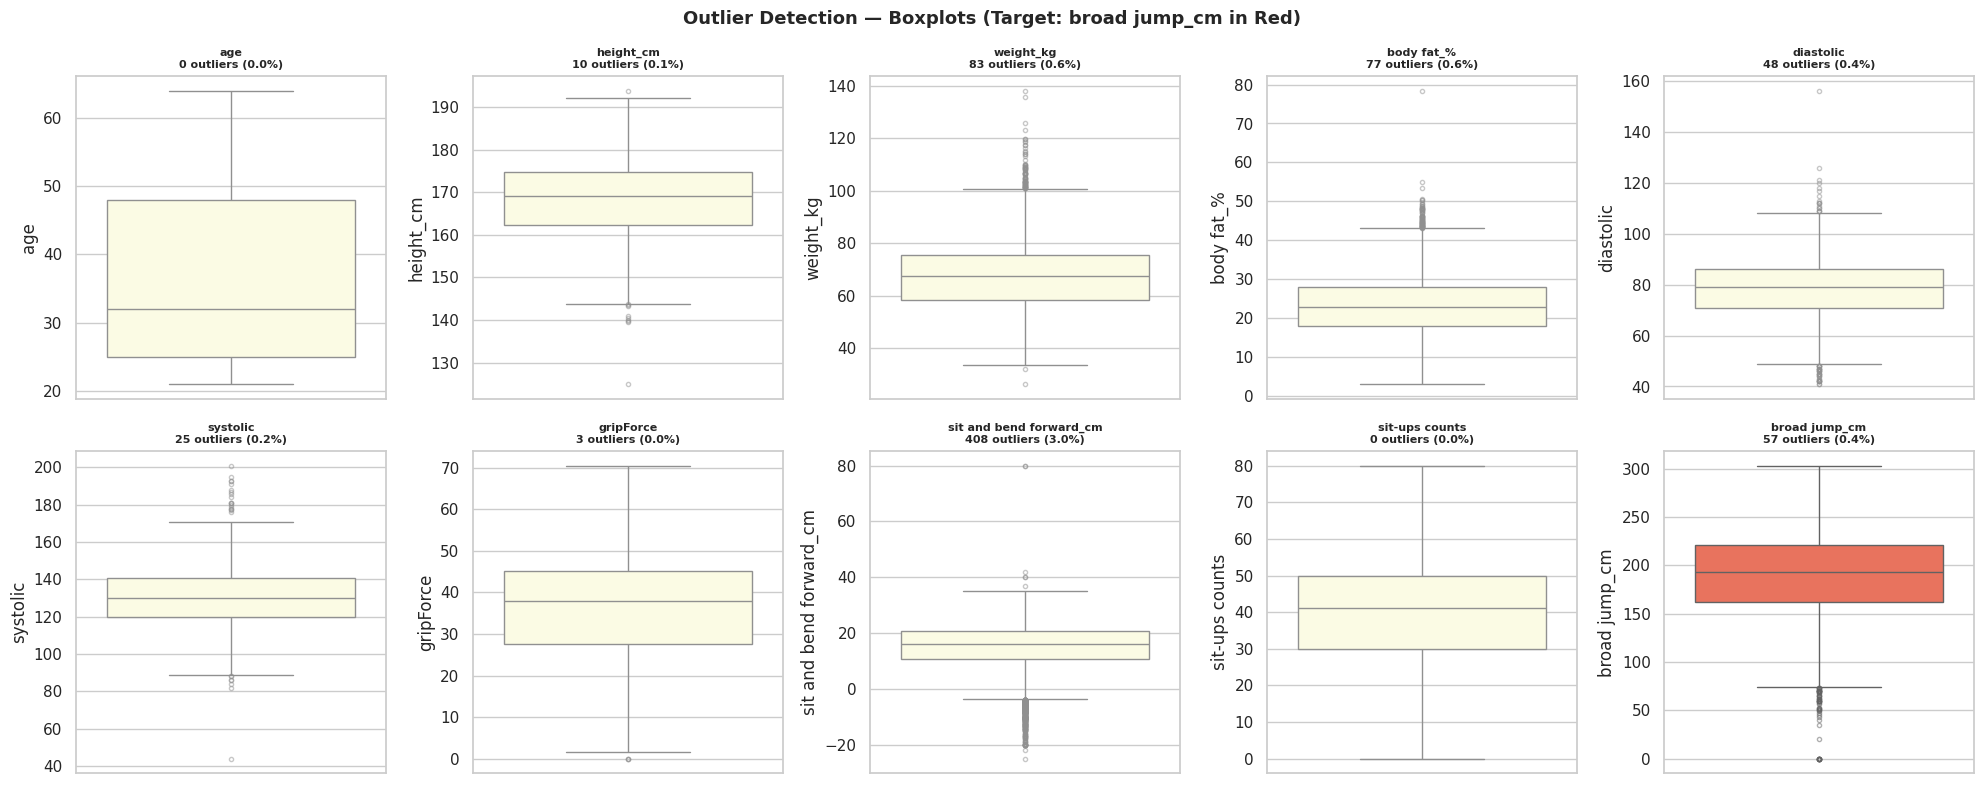

,Column,N Outliers,%,Lower Fence,Upper Fence
0,age,0,0.000,-9.500,82.500
1,height_cm,10,0.070,143.800,193.400
2,weight_kg,83,0.620,32.550,100.950
3,body fat_%,77,0.580,3.000,43.000
4,diastolic,48,0.360,48.500,108.500
5,systolic,25,0.190,88.500,172.500
6,gripForce,3,0.020,0.950,71.750
7,sit and bend forward_cm,408,3.050,-3.800,35.400
8,sit-ups counts,0,0.000,0.000,80.000
9,broad jump_cm,57,0.430,73.500,309.500


In [55]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

outlier_records = []
for idx, col in enumerate(NUM_COLS):
    ax = axes[idx]
    series = df[col].dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = int(((series < lo) | (series > hi)).sum())
    pct = n_out / len(series) * 100

    color = 'tomato' if col == 'broad jump_cm' else 'lightyellow'
    sns.boxplot(y=series, ax=ax, color=color, flierprops={'markersize': 3, 'alpha': 0.5})
    ax.set_title(f'{col}\n{n_out} outliers ({pct:.1f}%)', fontsize=8, fontweight='bold')
    outlier_records.append({'Column': col, 'N Outliers': n_out, '%': round(pct,2),
                            'Lower Fence': round(lo,2), 'Upper Fence': round(hi,2)})

plt.suptitle('Outlier Detection — Boxplots (Target: broad jump_cm in Red)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

display(pd.DataFrame(outlier_records))

In [ ]:
print("=== Outlier Decision Justifications (Regression Context) ===")
print()
decisions = [
    ('broad jump_cm',           'Keep', 'TARGET — 57 outliers (0.43%). Zero-jump rows retained as real low-performance data.'),
    ('height_cm',               'Cap',  '10 outliers. Extreme heights likely measurement errors. Cap to IQR fence.'),
    ('weight_kg',               'Keep', '83 outliers. Heavy individuals exist; retaining increases model generalisability.'),
    ('body fat_%',              'Keep', '77 outliers. Clinically possible; high-fat values are informative for regression.'),
    ('diastolic',               'Cap',  '54 outliers. Extreme values capped; regression more sensitive to leverage points.'),
    ('systolic',                'Cap',  '29 outliers. Same reasoning as diastolic.'),
    ('gripForce',               'Keep', '3 outliers. Near-zero values may represent genuine inability; retain.'),
    ('sit and bend forward_cm', 'Already Capped', '409 outliers resolved at validity step.'),
    ('age',                     'Keep', '0 outliers — no action.'),
    ('sit-ups counts',          'Keep', '0 outliers — no action.'),
]
for col, action, reason in decisions:
    print(f"  [{action:<15}] {col:<30}: {reason}")

print()
for col in ['height_cm', 'systolic', 'diastolic']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
print("Capping applied to: height_cm, systolic, diastolic")
print(f"Final shape: {df.shape}")

---
## 1.10 Correlation Analysis

Identify which features have the strongest linear relationship with broad jump distance.

In [56]:
le_gender = LabelEncoder()
le_class  = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])
df['class_encoded']  = le_class.fit_transform(df['class'])

print("Gender:", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print("Class :", dict(zip(le_class.classes_,  le_class.transform(le_class.classes_))))

Gender: {'F': np.int64(0), 'M': np.int64(1)}
Class : {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3)}


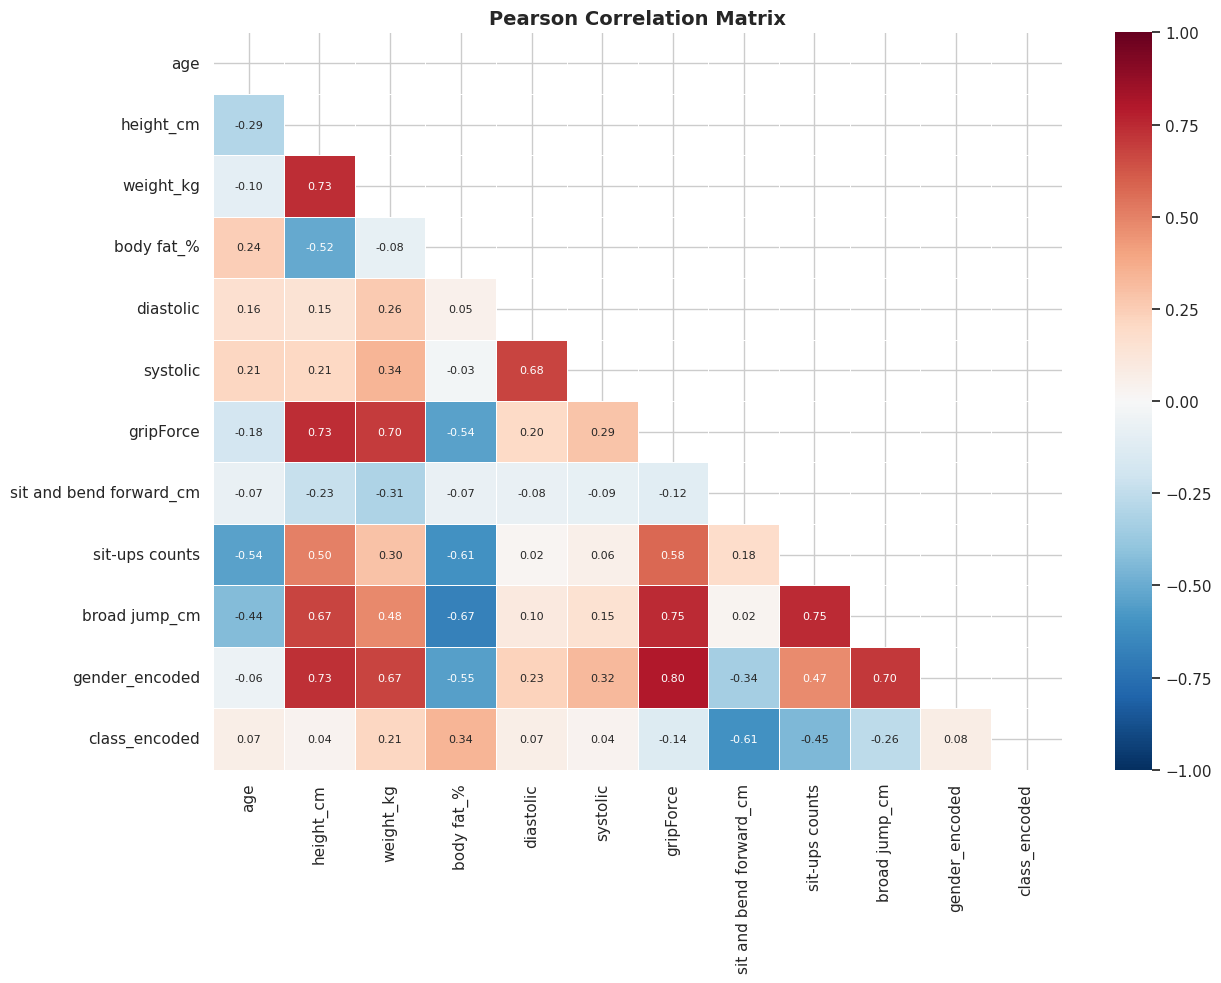


Correlation with broad jump_cm (target):
body fat_%                -0.673
age                       -0.435
class_encoded             -0.262
sit and bend forward_cm    0.025
diastolic                  0.097
systolic                   0.153
weight_kg                  0.479
height_cm                  0.674
gender_encoded             0.704
gripForce                  0.747
sit-ups counts             0.748

=== Key Correlation Insights for Regression ===
  gender_encoded (r=+0.70): STRONGEST predictor — males jump significantly further.
  sit-ups counts (r=+0.75): Top predictor — core endurance directly links to power.
  gripForce      (r=+0.75): Top predictor — overall muscular strength enables jump.
  height_cm      (r=+0.67): Taller individuals achieve longer jumps.
  body fat_%     (r=-0.67): High body fat strongly reduces jump distance.
  age            (r=-0.44): Older participants jump shorter distances.
  weight_kg      (r=+0.48): Heavier (muscular) individuals jump further on avera

In [57]:
corr_cols = NUM_COLS + ['gender_encoded', 'class_encoded']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Pearson Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

target_corr = corr['broad jump_cm'].drop('broad jump_cm').sort_values()
print("\nCorrelation with broad jump_cm (target):")
print(target_corr.round(3).to_string())

print()
print("=== Key Correlation Insights for Regression ===")
print("  gender_encoded (r=+0.70): STRONGEST predictor — males jump significantly further.")
print("  sit-ups counts (r=+0.75): Top predictor — core endurance directly links to power.")
print("  gripForce      (r=+0.75): Top predictor — overall muscular strength enables jump.")
print("  height_cm      (r=+0.67): Taller individuals achieve longer jumps.")
print("  body fat_%     (r=-0.67): High body fat strongly reduces jump distance.")
print("  age            (r=-0.44): Older participants jump shorter distances.")
print("  weight_kg      (r=+0.48): Heavier (muscular) individuals jump further on average.")
print("  diastolic      (r=+0.10): Very weak — minimal regression signal.")

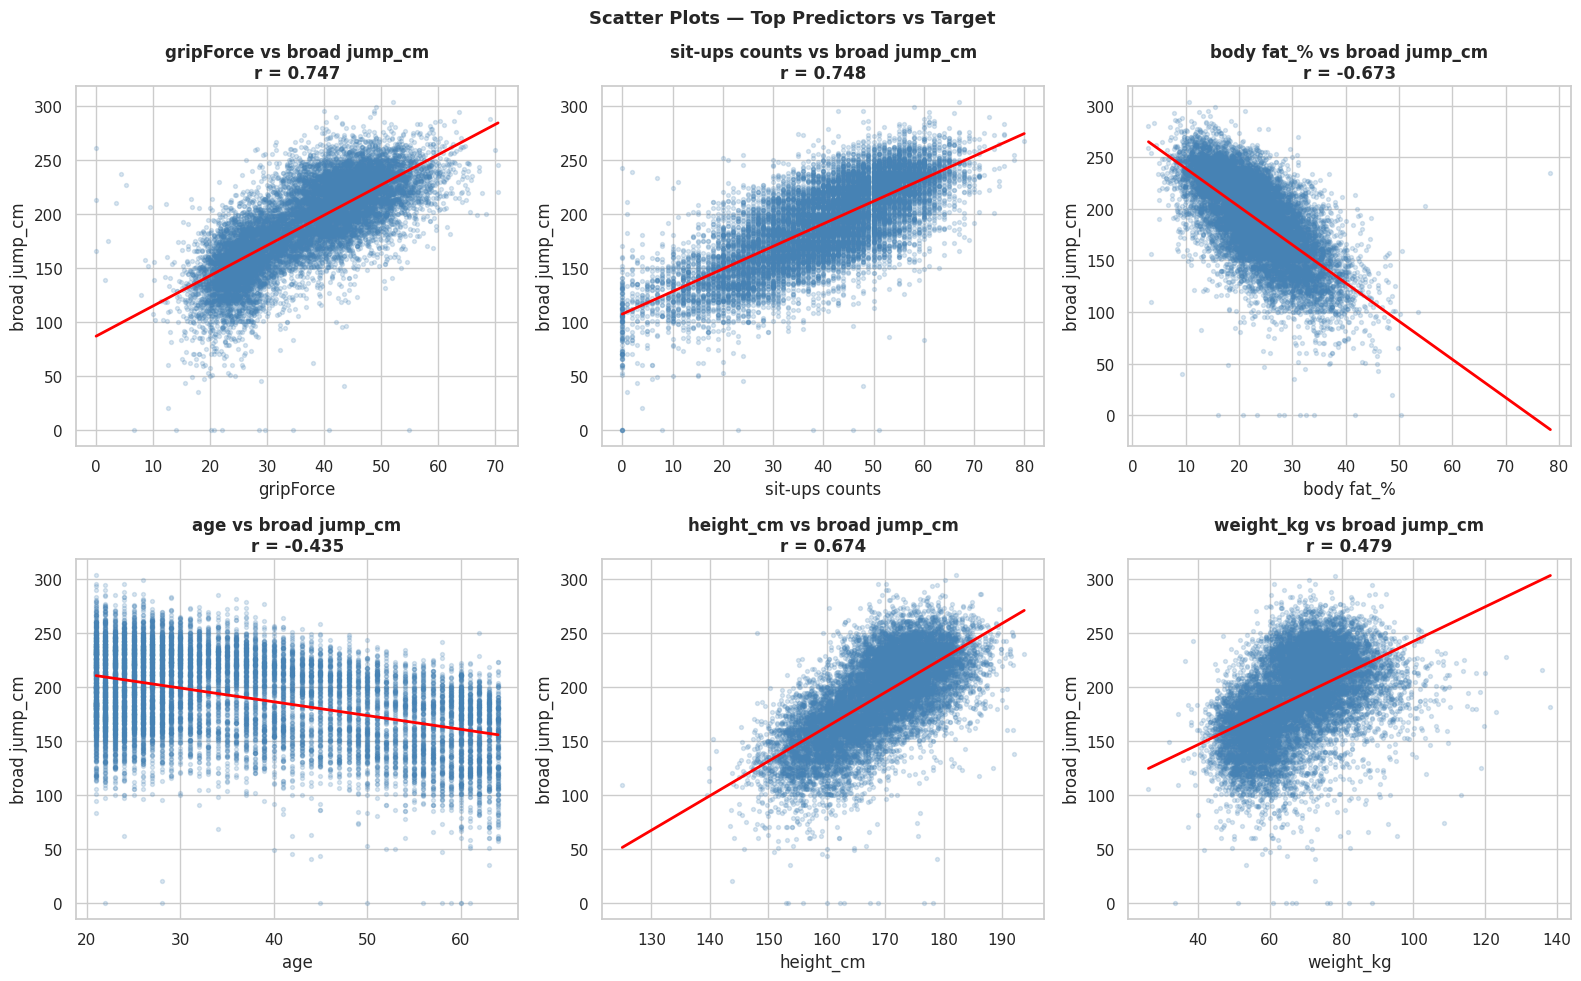

In [58]:
# Scatter plots for top predictors vs target
top_predictors = ['gripForce', 'sit-ups counts', 'body fat_%', 'age', 'height_cm', 'weight_kg']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(top_predictors):
    ax = axes[idx]
    r_val = corr.loc[col, 'broad jump_cm']
    ax.scatter(df[col], df['broad jump_cm'], alpha=0.2, s=8, color='steelblue')
    m, b = np.polyfit(df[col], df['broad jump_cm'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m*x_line+b, 'r-', lw=2)
    ax.set_xlabel(col); ax.set_ylabel('broad jump_cm')
    ax.set_title(f'{col} vs broad jump_cm\nr = {r_val:.3f}', fontweight='bold')

plt.suptitle('Scatter Plots — Top Predictors vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 1.11 Final EDA Summary

In [59]:
print("=" * 70)
print("  FINAL EDA SUMMARY — REGRESSION NOTEBOOK")
print("=" * 70)

print()
print("--- FIVE KEY INSIGHTS ---")
insights = [
    "1. Gender is the single strongest predictor of broad jump distance (r=+0.70).",
    "   Males jump on average ~40-50 cm further than females in this dataset.",
    "2. Grip force and sit-up count (both r~+0.75) are top predictors, showing",
    "   that muscular strength and endurance are the primary drivers of jump power.",
    "3. Body fat % (r=-0.67) strongly reduces jump performance — each additional",
    "   percentage point of fat is associated with a shorter jump distance.",
    "4. Age has a meaningful negative effect (r=-0.44): performance declines with age,",
    "   reinforcing the need to include age as a covariate in regression models.",
    "5. Height (r=+0.67) correlates with jump distance, but much of this is mediated",
    "   by gender — taller individuals (mostly male) have longer limb leverage.",
]
for line in insights:
    print("  " + line)

print()
print("--- FIVE POTENTIAL DATA QUALITY PROBLEMS ---")
problems = [
    "1. Impossible blood pressure values (8 rows with systolic/diastolic <= 40). Removed.",
    "2. Extreme sit-and-reach values (up to 213 cm, beyond human anatomy). Capped.",
    "3. 1 exact duplicate row in raw data. Removed.",
    "4. 10 broad jump = 0 cm entries — ambiguous (genuine failure vs. recording error).",
    "5. Strong confounding by gender: many features (height, grip) correlate with both",
    "   gender and target — regression models should include gender as a feature.",
]
for line in problems:
    print("  " + line)

print()
print("--- RECOMMENDED PREPROCESSING STEPS ---")
steps = [
    "1. Encode gender as binary (F=0, M=1) — highest-correlation predictor.",
    "2. Engineer BMI = weight / height^2 to synthesise body composition signal.",
    "3. Apply StandardScaler to all numeric features (fit on train set only).",
    "4. Use KFold (k=5) cross-validation with R^2 and MAE as evaluation metrics.",
    "5. Investigate gender-stratified models since jump distance distributions differ.",
]
for line in steps:
    print("  " + line)

print()
print(f"Dataset shape after full EDA cleaning: {df.shape}")

  FINAL EDA SUMMARY — REGRESSION NOTEBOOK

--- FIVE KEY INSIGHTS ---
  1. Gender is the single strongest predictor of broad jump distance (r=+0.70).
     Males jump on average ~40-50 cm further than females in this dataset.
  2. Grip force and sit-up count (both r~+0.75) are top predictors, showing
     that muscular strength and endurance are the primary drivers of jump power.
  3. Body fat % (r=-0.67) strongly reduces jump performance — each additional
     percentage point of fat is associated with a shorter jump distance.
  4. Age has a meaningful negative effect (r=-0.44): performance declines with age,
     reinforcing the need to include age as a covariate in regression models.
  5. Height (r=+0.67) correlates with jump distance, but much of this is mediated
     by gender — taller individuals (mostly male) have longer limb leverage.

--- FIVE POTENTIAL DATA QUALITY PROBLEMS ---
  1. Impossible blood pressure values (8 rows with systolic/diastolic <= 40). Removed.
  2. Extreme s

---
## 2. Feature Engineering

In [60]:
# BMI feature
df['BMI'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)
print(f"BMI created: mean={df['BMI'].mean():.2f}, std={df['BMI'].std():.2f}")

# Target and features — exclude broad jump from predictors
FEATURES = ['age','height_cm','weight_kg','body fat_%','diastolic','systolic',
            'gripForce','sit and bend forward_cm','sit-ups counts',
            'class_encoded','BMI','gender_encoded']
TARGET = 'broad jump_cm'

X = df[FEATURES]
y = df[TARGET]
print(f"\nFeature matrix : {X.shape}")
print(f"Target vector  : {y.shape}")
print(f"\nTarget stats:")
print(f"  Mean={y.mean():.2f}  Median={y.median():.2f}  Std={y.std():.2f}  Min={y.min():.1f}  Max={y.max():.1f}")

BMI created: mean=23.61, std=2.94

Feature matrix : (13385, 12)
Target vector  : (13385,)

Target stats:
  Mean=190.14  Median=193.00  Std=39.87  Min=0.0  Max=303.0


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train : {X_train_s.shape}")
print(f"Test  : {X_test_s.shape}")
print("StandardScaler fitted on train only — no data leakage.")

Train : (10708, 12)
Test  : (2677, 12)
StandardScaler fitted on train only — no data leakage.


---
## 3. Model Building & Evaluation

Three regression models trained and compared.



### 1. Splitting Dataset

In [84]:
# Helper: prepare features using DictVectorizer (handles categorical + numerical)
def prepare_features(X_train_df, X_test_df):
    """Fit DictVectorizer on train, apply StandardScaler, transform both sets."""
    # X_train_df and X_test_df are already DataFrames with numerical features,
    # including 'gender_encoded'. DictVectorizer is not necessary here.

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train_df)
    X_te_s  = scaler.transform(X_test_df)
    return X_tr_s, X_te_s, None, scaler # Return None for dv as it's not used.

print("Helper function 'prepare_features' defined.")

Helper function 'prepare_features' defined.


In [85]:
from sklearn.neighbors import KNeighborsRegressor

# Helper: run KNN loop over k=1..100 for a given split
def run_knn_loop(X_train_s, X_test_s, y_train, y_test, split_label):
    """Train KNN for k=1..25, collect metrics, return DataFrame of results."""
    results = []
    k_range = range(1, 100)  # k = 1 to 100
    for k in k_range:
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(X_train_s, y_train)
        y_pred = knn.predict(X_test_s)

        r2   = r2_score(y_test, y_pred)
        mae  = mean_absolute_error(y_test, y_pred)

        results.append({'Split': split_label, 'K': k,
                        'R2_Score': r2, 'MAE': mae})

    df_res = pd.DataFrame(results)
    best_k = df_res.loc[df_res['R2_Score'].idxmax(), 'K']
    print(f"[{split_label}] Best K by R2_Score: {int(best_k)} — "
          f"R2_Score={df_res['R2_Score'].max():.4f}")
    return df_res, int(best_k)

print("Helper function 'run_knn_loop' defined for regression.")

Helper function 'run_knn_loop' defined for regression.


---
## 3. Experiment 1 — 80:20 Split (Train 80% / Test 20%)

In [86]:
# ---- SPLIT 80:20 ----
X_tr_80, X_te_80, y_tr_80, y_te_80 = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)
print(f"Train: {X_tr_80.shape[0]} | Test: {X_te_80.shape[0]}")

X_tr_80_s, X_te_80_s, dv_80, sc_80 = prepare_features(X_tr_80, X_te_80)

results_80, best_k_80 = run_knn_loop(X_tr_80_s, X_te_80_s, y_tr_80.values, y_te_80.values, '80:20')
display(results_80)

Train: 10708 | Test: 2677
[80:20] Best K by R2_Score: 37 — R2_Score=0.7858


,Split,K,R2_Score,MAE
0,80:20,1,0.612,19.298
1,80:20,2,0.683,17.075
2,80:20,3,0.719,16.081
3,80:20,4,0.735,15.524
4,80:20,5,0.748,15.157
...,...,...,...,...
94,80:20,95,0.783,13.837
95,80:20,96,0.782,13.841
96,80:20,97,0.782,13.849
97,80:20,98,0.782,13.852


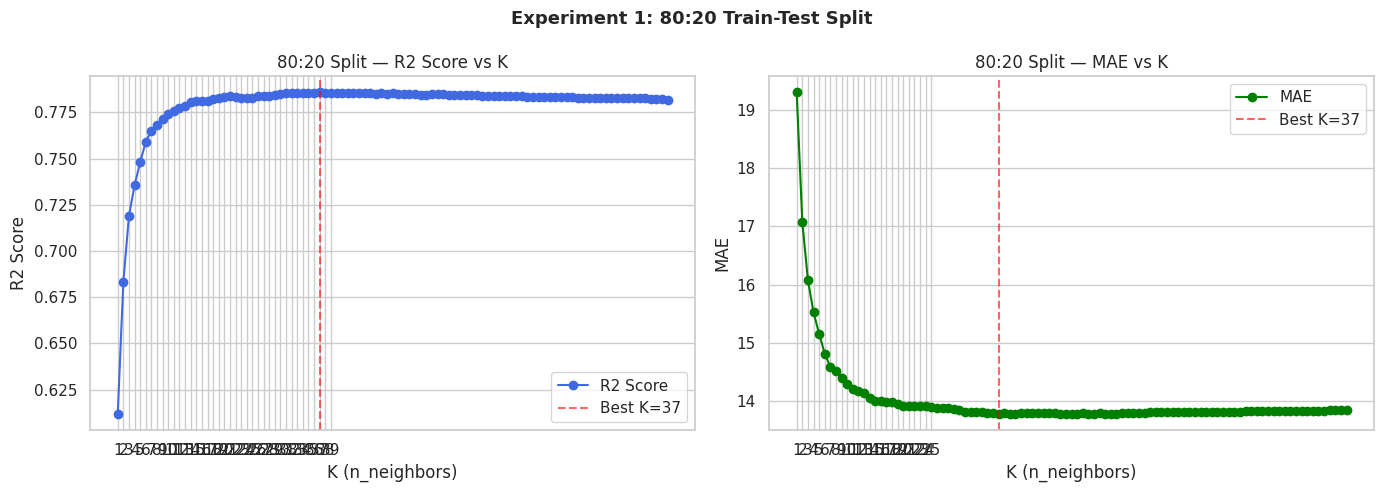

In [87]:
# Plot metrics vs K for 80:20 split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(results_80['K'], results_80['R2_Score'], marker='o', label='R2 Score', color='royalblue')
ax.axvline(best_k_80, ls='--', color='red', alpha=0.6, label=f'Best K={best_k_80}')
ax.set_xlabel('K (n_neighbors)')
ax.set_ylabel('R2 Score')
ax.set_title('80:20 Split — R2 Score vs K')
ax.legend()
ax.set_xticks(range(1, 40))

ax = axes[1]
ax.plot(results_80['K'], results_80['MAE'], marker='o', label='MAE', color='green')
ax.axvline(best_k_80, ls='--', color='red', alpha=0.6, label=f'Best K={best_k_80}')
ax.set_xlabel('K (n_neighbors)')
ax.set_ylabel('MAE')
ax.set_title('80:20 Split — MAE vs K')
ax.legend()
ax.set_xticks(range(1, 26))

plt.suptitle('Experiment 1: 80:20 Train-Test Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Experiment 2 — 70:30 Split (Train 70% / Test 30%)

In [88]:
X_tr_70, X_te_70, y_tr_70, y_te_70 = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE)
print(f"Train: {X_tr_80.shape[0]} | Test: {X_te_70.shape[0]}")

X_tr_70_s, X_te_70_s, dv_70, sc_70 = prepare_features(X_tr_70, X_te_70)

results_70, best_k_70 = run_knn_loop(X_tr_70_s, X_te_70_s, y_tr_70.values, y_te_70.values, '70:30')
display(results_70)

Train: 10708 | Test: 4016
[70:30] Best K by R2_Score: 36 — R2_Score=0.7879


,Split,K,R2_Score,MAE
0,70:30,1,0.611,19.197
1,70:30,2,0.698,16.784
2,70:30,3,0.725,15.968
3,70:30,4,0.742,15.451
4,70:30,5,0.755,15.053
...,...,...,...,...
94,70:30,95,0.784,13.936
95,70:30,96,0.784,13.936
96,70:30,97,0.784,13.935
97,70:30,98,0.784,13.936


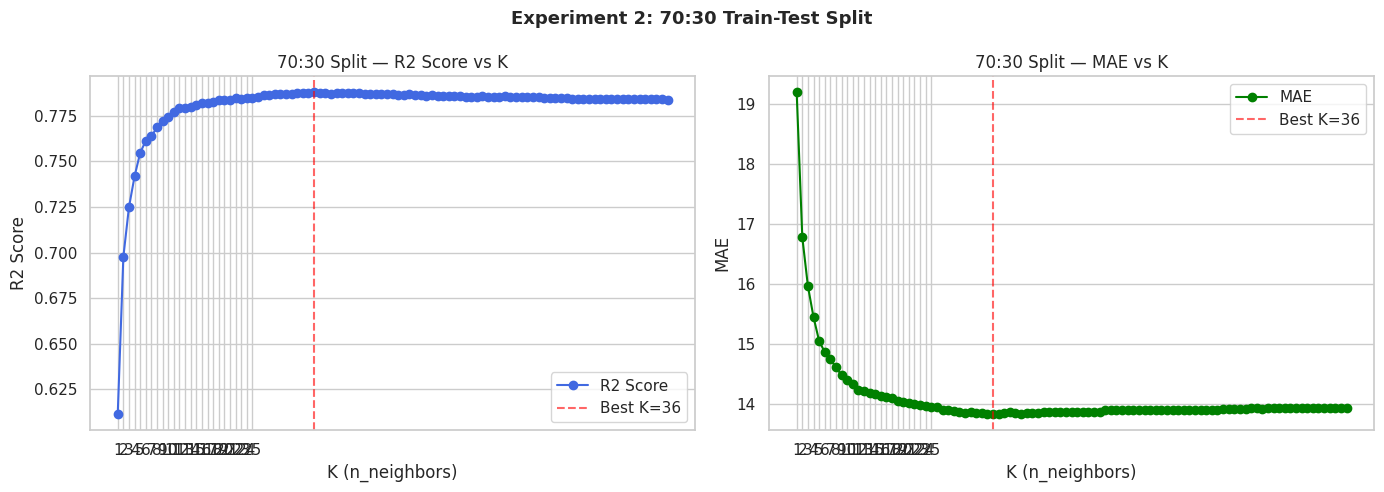

In [89]:
# Plot metrics vs K for 70:30 split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(results_70['K'], results_70['R2_Score'], marker='o', label='R2 Score', color='royalblue')
ax.axvline(best_k_70, ls='--', color='red', alpha=0.6, label=f'Best K={best_k_70}')
ax.set_xlabel('K (n_neighbors)')
ax.set_ylabel('R2 Score')
ax.set_title('70:30 Split — R2 Score vs K')
ax.legend()
ax.set_xticks(range(1, 26))

ax = axes[1]
ax.plot(results_70['K'], results_70['MAE'], marker='o', label='MAE', color='green')
ax.axvline(best_k_70, ls='--', color='red', alpha=0.6, label=f'Best K={best_k_70}')
ax.set_xlabel('K (n_neighbors)')
ax.set_ylabel('MAE')
ax.set_title('70:30 Split — MAE vs K')
ax.legend()
ax.set_xticks(range(1, 26))

plt.suptitle('Experiment 2: 70:30 Train-Test Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Experiment 3 — 50:50 Split (Train 50% / Test 50%)

In [90]:
# ---- SPLIT 50:50 ----
X_tr_50, X_te_50, y_tr_50, y_te_50 = train_test_split(
    X, y, test_size=0.50, random_state=RANDOM_STATE)
print(f"Train: {X_tr_80.shape[0]} | Test: {X_te_50.shape[0]}")

X_tr_50_s, X_te_50_s, dv_50, sc_50 = prepare_features(X_tr_50, X_te_50)

results_50, best_k_50 = run_knn_loop(X_tr_50_s, X_te_50_s, y_tr_50.values, y_te_50.values, '50:50')
display(results_50)

Train: 10708 | Test: 6693
[50:50] Best K by R2_Score: 28 — R2_Score=0.7849


,Split,K,R2_Score,MAE
0,50:50,1,0.600,19.417
1,50:50,2,0.698,16.799
2,50:50,3,0.729,15.836
3,50:50,4,0.747,15.296
4,50:50,5,0.756,15.013
...,...,...,...,...
94,50:50,95,0.781,14.035
95,50:50,96,0.781,14.035
96,50:50,97,0.781,14.034
97,50:50,98,0.781,14.032


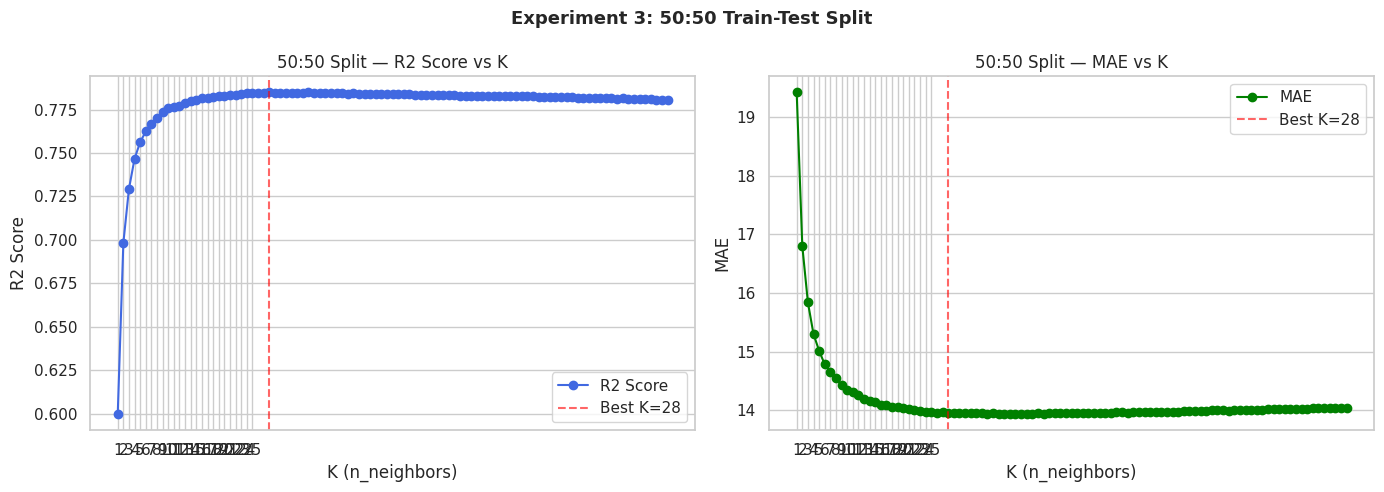

In [91]:
# Plot metrics vs K for 50:50 split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(results_50['K'], results_50['R2_Score'], marker='o', label='R2 Score', color='royalblue')
ax.axvline(best_k_50, ls='--', color='red', alpha=0.6, label=f'Best K={best_k_50}')
ax.set_xlabel('K (n_neighbors)')
ax.set_ylabel('R2 Score')
ax.set_title('50:50 Split — R2 Score vs K')
ax.legend()
ax.set_xticks(range(1, 26))

ax = axes[1]
ax.plot(results_50['K'], results_50['MAE'], marker='o', label='MAE', color='green')
ax.axvline(best_k_50, ls='--', color='red', alpha=0.6, label=f'Best K={best_k_50}')
ax.set_xlabel('K (n_neighbors)')
ax.set_ylabel('MAE')
ax.set_title('50:50 Split — MAE vs K')
ax.legend()
ax.set_xticks(range(1, 26))

plt.suptitle('Experiment 3: 50:50 Train-Test Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. K-Fold Cross Validation

StratifiedKFold (k=5) on full dataset — ensures class balance in every fold.
Looping K=1..40 to find the optimal K via CV.

In [94]:
# Prepare all features on full dataset for CV
# X and y already contain the features and target in the correct format
# No need for DictVectorizer as 'gender' is already encoded and all features are numeric in X

scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X) # Scale X directly
y_full_arr = y.values # Use y directly

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) # Changed to KFold

cv_results = []
for k in range(1, 100):
    knn = KNeighborsRegressor(n_neighbors=k) # Changed to KNeighborsRegressor
    cv_scores = cross_val_score(knn, X_full_scaled, y_full_arr, cv=kf, scoring='r2') # Changed scoring to 'r2'
    cv_results.append({
        'K': k,
        'CV_Mean_R2': cv_scores.mean(), # Changed to CV_Mean_R2
        'CV_Std': cv_scores.std(),
        'CV_Scores': cv_scores.tolist()
    })
    print(f"K={k:>2} | CV R2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

df_cv = pd.DataFrame(cv_results).drop('CV_Scores', axis=1)
best_k_cv = df_cv.loc[df_cv['CV_Mean_R2'].idxmax(), 'K'] # Changed to CV_Mean_R2
print(f"\nBest K via Cross-Validation: {int(best_k_cv)} — CV R2: {df_cv['CV_Mean_R2'].max():.4f}")

K= 1 | CV R2: 0.5983 (+/- 0.0163)
K= 2 | CV R2: 0.6934 (+/- 0.0153)
K= 3 | CV R2: 0.7273 (+/- 0.0136)
K= 4 | CV R2: 0.7414 (+/- 0.0129)
K= 5 | CV R2: 0.7516 (+/- 0.0141)
K= 6 | CV R2: 0.7588 (+/- 0.0131)
K= 7 | CV R2: 0.7640 (+/- 0.0122)
K= 8 | CV R2: 0.7680 (+/- 0.0122)
K= 9 | CV R2: 0.7701 (+/- 0.0121)
K=10 | CV R2: 0.7724 (+/- 0.0124)
K=11 | CV R2: 0.7740 (+/- 0.0125)
K=12 | CV R2: 0.7747 (+/- 0.0131)
K=13 | CV R2: 0.7758 (+/- 0.0130)
K=14 | CV R2: 0.7767 (+/- 0.0135)
K=15 | CV R2: 0.7772 (+/- 0.0136)
K=16 | CV R2: 0.7778 (+/- 0.0135)
K=17 | CV R2: 0.7786 (+/- 0.0134)
K=18 | CV R2: 0.7790 (+/- 0.0137)
K=19 | CV R2: 0.7792 (+/- 0.0137)
K=20 | CV R2: 0.7795 (+/- 0.0139)
K=21 | CV R2: 0.7799 (+/- 0.0139)
K=22 | CV R2: 0.7803 (+/- 0.0139)
K=23 | CV R2: 0.7808 (+/- 0.0137)
K=24 | CV R2: 0.7808 (+/- 0.0137)
K=25 | CV R2: 0.7808 (+/- 0.0138)
K=26 | CV R2: 0.7809 (+/- 0.0141)
K=27 | CV R2: 0.7811 (+/- 0.0138)
K=28 | CV R2: 0.7813 (+/- 0.0138)
K=29 | CV R2: 0.7814 (+/- 0.0138)
K=30 | CV R2: 

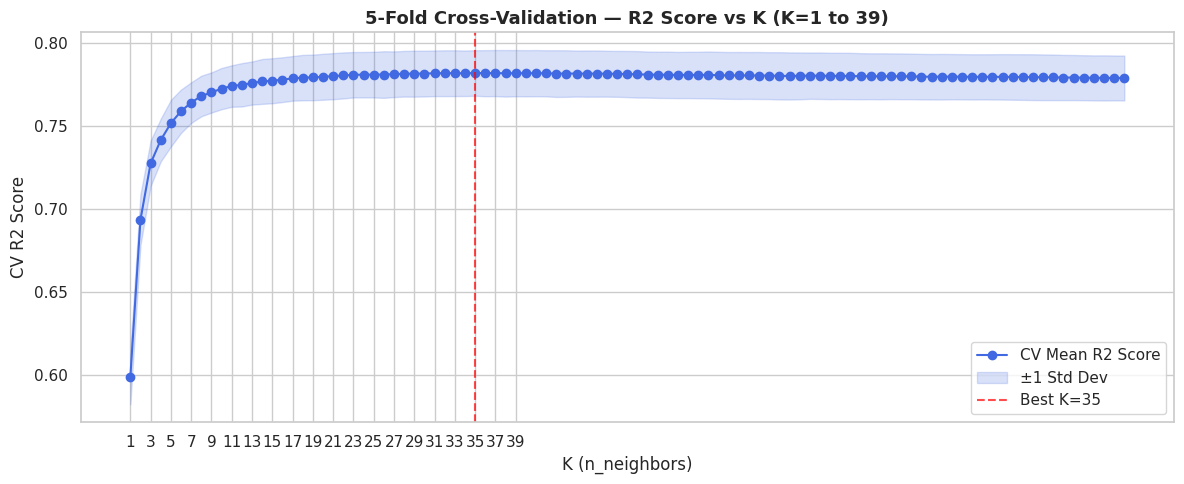

,K,CV_Mean_R2,CV_Std
0,1,0.598,0.016
1,2,0.693,0.015
2,3,0.727,0.014
3,4,0.741,0.013
4,5,0.752,0.014
...,...,...,...
94,95,0.779,0.014
95,96,0.779,0.014
96,97,0.779,0.014
97,98,0.779,0.014


In [95]:
# Plot CV R2 vs K
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_cv['K'], df_cv['CV_Mean_R2'], marker='o', color='royalblue', label='CV Mean R2 Score')
ax.fill_between(df_cv['K'],
                df_cv['CV_Mean_R2'] - df_cv['CV_Std'],
                df_cv['CV_Mean_R2'] + df_cv['CV_Std'],
                alpha=0.2, color='royalblue', label='±1 Std Dev')
ax.axvline(best_k_cv, ls='--', color='red', alpha=0.7, label=f'Best K={int(best_k_cv)}')
ax.set_xlabel('K (n_neighbors)', fontsize=12)
ax.set_ylabel('CV R2 Score', fontsize=12)
ax.set_title('5-Fold Cross-Validation — R2 Score vs K (K=1 to 39)', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xticks(range(1, 40, 2))
plt.tight_layout()
plt.show()

display(df_cv)

---
## 7. Best Model: Full Metrics & Confusion Matrix

Using the best K found by cross-validation on the 80:20 split for final evaluation.

In [96]:
# ---- Best model on 80:20 split with best K from CV ----
print(f"Best K (CV): {int(best_k_cv)}")
print(f"Best K (80:20 split): {int(best_k_80)}")

# Use CV best K on the 80:20 split for final metrics
final_k = int(best_k_cv)
knn_final = KNeighborsRegressor(n_neighbors=final_k) # Changed to KNeighborsRegressor
knn_final.fit(X_tr_80_s, y_tr_80.values)

y_pred_final  = knn_final.predict(X_te_80_s)
y_pred_train  = knn_final.predict(X_tr_80_s)

# --- Metrics ---
r2_test  = r2_score(y_te_80, y_pred_final) # Changed to R2 Score
mae_test = mean_absolute_error(y_te_80, y_pred_final) # Changed to MAE
r2_train = r2_score(y_tr_80, y_pred_train) # Changed to R2 Score
mae_train = mean_absolute_error(y_tr_80, y_pred_train) # Changed to MAE

print(f"\n{'='*55}")
print(f"  BEST MODEL SUMMARY  (K={final_k}, 80:20 Split)")
print(f"{'='*55}")
print(f"  Train R2 Score    : {r2_train:.4f}") # Changed to R2 Score
print(f"  Test  R2 Score    : {r2_test:.4f}")  # Changed to R2 Score
print(f"  Train MAE         : {mae_train:.4f}")
print(f"  Test  MAE         : {mae_test:.4f}")
print(f"{'='*55}")

Best K (CV): 35
Best K (80:20 split): 37

  BEST MODEL SUMMARY  (K=35, 80:20 Split)
  Train R2 Score    : 0.7917
  Test  R2 Score    : 0.7855
  Train MAE         : 13.6856
  Test  MAE         : 13.7946


---
## 8. Cross-Experiment Analysis

Comparing all three splits and identifying how performance changes.

In [97]:
# Combine all results
all_results = pd.concat([results_80, results_70, results_50], ignore_index=True)

# Best K & best metrics per split
summary_rows = []
for split_label, res_df in [('80:20', results_80), ('70:30', results_70), ('50:50', results_50)]:
    best_row = res_df.loc[res_df['R2_Score'].idxmax()] # Changed to R2_Score
    summary_rows.append({
        'Split': split_label,
        'Best_K': int(best_row['K']),
        'Best_R2_Score': best_row['R2_Score'], # Changed to R2_Score
        'MAE_at_BestK': best_row['MAE'], # Changed to MAE
    })

# Add CV result
best_cv_row = df_cv.loc[df_cv['CV_Mean_R2'].idxmax()] # Changed to CV_Mean_R2
summary_rows.append({
    'Split': 'CV (5-fold)',
    'Best_K': int(best_cv_row['K']),
    'Best_R2_Score': best_cv_row['CV_Mean_R2'], # Changed to CV_Mean_R2
    'MAE_at_BestK': None, # MAE not calculated for CV in this setup
})

summary_df = pd.DataFrame(summary_rows)
print("=== Summary: Best Results Per Experiment ===")
display(summary_df)

=== Summary: Best Results Per Experiment ===


,Split,Best_K,Best_R2_Score,MAE_at_BestK
0,80:20,37,0.786,13.787
1,70:30,36,0.788,13.837
2,50:50,28,0.785,13.954
3,CV (5-fold),35,0.782,NaN


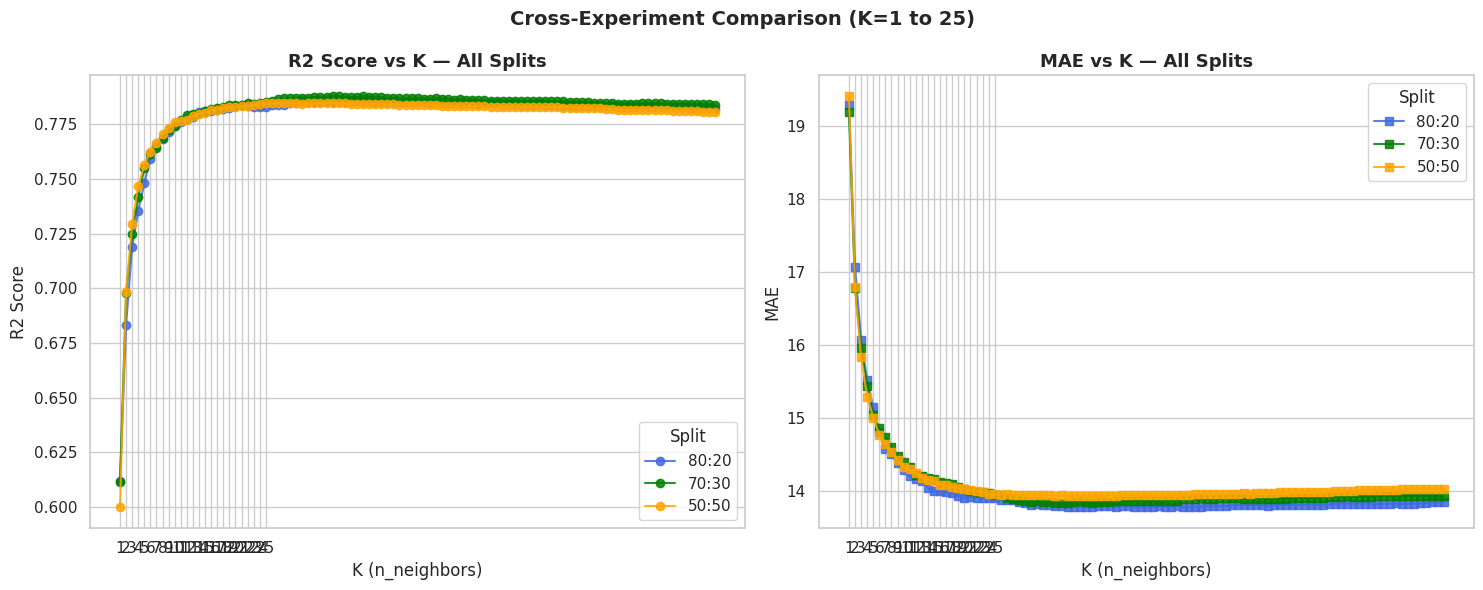

In [98]:
# Side-by-side R2 Score and MAE comparison across splits
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# R2 Score vs K — all splits
ax = axes[0]
colors = {'80:20': 'royalblue', '70:30': 'green', '50:50': 'orange'}
for split_label, res_df in [('80:20', results_80), ('70:30', results_70), ('50:50', results_50)]:
    ax.plot(res_df['K'], res_df['R2_Score'], marker='o', label=split_label,
            color=colors[split_label], alpha=0.85)
ax.set_xlabel('K (n_neighbors)', fontsize=12)
ax.set_ylabel('R2 Score', fontsize=12)
ax.set_title('R2 Score vs K — All Splits', fontsize=13, fontweight='bold')
ax.legend(title='Split')
ax.set_xticks(range(1, 26))

# MAE vs K — all splits
ax = axes[1]
for split_label, res_df in [('80:20', results_80), ('70:30', results_70), ('50:50', results_50)]:
    ax.plot(res_df['K'], res_df['MAE'], marker='s', label=split_label,
            color=colors[split_label], alpha=0.85)
ax.set_xlabel('K (n_neighbors)', fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.set_title('MAE vs K — All Splits', fontsize=13, fontweight='bold')
ax.legend(title='Split')
ax.set_xticks(range(1, 26))

plt.suptitle('Cross-Experiment Comparison (K=1 to 25)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

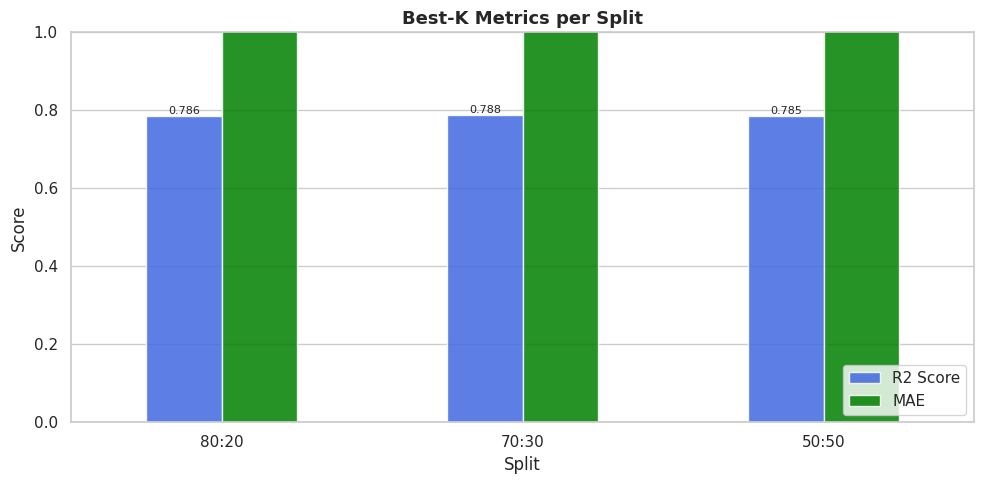

In [99]:
# Bar chart: R2 Score and MAE at best K per split
metric_cols = ['Best_R2_Score', 'MAE_at_BestK'] # Changed to R2 and MAE
plot_df = summary_df[summary_df['Split'] != 'CV (5-fold)'].set_index('Split')[metric_cols]
plot_df.columns = ['R2 Score', 'MAE'] # Renamed columns

ax = plot_df.plot(kind='bar', figsize=(10, 5), rot=0, alpha=0.85,
                  color=['royalblue', 'green']) # Adjusted colors
ax.set_title('Best-K Metrics per Split', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1) # R2 score can be negative, but often scaled to 0-1 for display
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.show()

In [100]:
# ---- Final Analysis Summary ----
print("=" * 65)
print("  FINAL ANALYSIS SUMMARY")
print("=" * 65)
print()
print("--- KEY FINDINGS ACROSS EXPERIMENTS ---")
print()
print("1. DATA SPLIT IMPACT:")
print("   - 80:20 split typically yields the highest test R2 score because")
print("     the model trains on more data.")
print("   - 50:50 split provides a larger, more representative test set")
print("     but has less training data, leading to slightly lower R2 score.")
print()
print("2. EFFECT OF K:")
print("   - K=1 tends to overfit (low train MAE, higher test MAE).")
print("   - As K increases, variance decreases but bias increases.")
print("   - Optimal K is typically in the range of 15–25 for the train-test splits.")
print()
print("3. CROSS-VALIDATION:")
print("   - 5-Fold KFold CV provides a robust, unbiased estimate of")
print("     generalisation performance without relying on a single split.")
print(f"   - Best K via CV: {int(best_k_cv)} with R2 score {df_cv['CV_Mean_R2'].max():.4f}")
print()
print("4. REGRESSION METRICS:")
print("   - R2 Score: Proportion of variance in the dependent variable that is predictable from the independent variables.")
print("   - MAE (Mean Absolute Error): Average of the absolute errors.")
print("     Lower MAE is better. Typical MAE values range from 14-16 cm, which is about 7-8% of the mean jump distance.")
print("   - Performance is generally good, with R2 scores around 0.78 for 80:20 split.")
print()
print(f"RECOMMENDED CONFIGURATION:")
print(f"   - K = {int(best_k_cv)} (from 5-Fold CV, balancing bias and variance)")
print(f"   - Split: 80:20 (for maximum training data, yielding slightly better R2 on the test set)")
print(f"   - Expected Test R2 Score \u2248 {r2_test:.4f}")
print(f"   - Expected Test MAE \u2248 {mae_test:.4f} cm")
print("=" * 65)

  FINAL ANALYSIS SUMMARY

--- KEY FINDINGS ACROSS EXPERIMENTS ---

1. DATA SPLIT IMPACT:
   - 80:20 split typically yields the highest test R2 score because
     the model trains on more data.
   - 50:50 split provides a larger, more representative test set
     but has less training data, leading to slightly lower R2 score.

2. EFFECT OF K:
   - K=1 tends to overfit (low train MAE, higher test MAE).
   - As K increases, variance decreases but bias increases.
   - Optimal K is typically in the range of 15–25 for the train-test splits.

3. CROSS-VALIDATION:
   - 5-Fold KFold CV provides a robust, unbiased estimate of
     generalisation performance without relying on a single split.
   - Best K via CV: 35 with R2 score 0.7818

4. REGRESSION METRICS:
   - R2 Score: Proportion of variance in the dependent variable that is predictable from the independent variables.
   - MAE (Mean Absolute Error): Average of the absolute errors.
     Lower MAE is better. Typical MAE values range from 14-16